# What is control? States, controls, targets and feedback

*Introduction to Control and Machine Learning · Part I: Control · Notebook 01*

> **Central question.** *What does it mean mathematically to act on a dynamical system?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 45–55 min · DEEPER LOOK ≈ 5 min more |
| **Execution time** | a few seconds |
| **Exercises** | 5 exercises, ≈ 45–75 min |
| **Prerequisites** | linear ODEs with constant coefficients; complex numbers; [notebook 00](00_course_map.ipynb) is a useful map but not required |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 7–16, 19, 22–38, 70, 137–140, 286 (see the Source map at the end) |
| **Notation** | `notation.md` §1 and §10 (E1). **Local overloads:** $k$ denotes the damping coefficient (not an iteration index), and $L$ a feedback gain, as in notebook 05 |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

**Learning objectives.** After this notebook you should be able to

1. formulate a control problem as a state equation, a set of admissible controls and an objective;
2. distinguish **controllability** (can a prescribed target be reached?), **optimal control** (which admissible control is best for a cost?) and **stabilization** (is there a rule that drives the system towards equilibrium?);
3. explain the difference between open-loop and closed-loop (feedback) control, and how feedback attenuates the effect of an unknown constant disturbance in the thermostat example;
4. derive the characteristic roots of $x_1''+kx_1'+x_1=0$ and classify under-, critical and over-damping;
5. explain why increasing the damping indefinitely does **not** accelerate the return to rest.

## Where are we?
`CORE`

This is the first technical notebook. [Notebook 00](00_course_map.ipynb) gave the map: a system has a *state* that evolves in time, we act on it through a *control*, and we want to reach a *target*. Here we make these words precise, compare the three basic control questions, and study the first example where intuition about control fails, the overdamped oscillator.

## 1. The ingredients of a control problem
`CORE`

The slides start from an abstract **state equation** (PDF p. 10)
$$
A(y)=f(v),
$$
in which $y$ is the **state** to be controlled and $v$ is the **control**, taken from a set of **admissible controls** $U_{ad}$. Roughly, the goal is to drive the state close to a desired state $y_d$.

The same framework covers very different models (p. 11): linear or nonlinear, deterministic or stochastic, finite- or infinite-dimensional, and ordinary or partial differential equations, as well as hybrid models.

> **Remark on notation.** The slides use $(y,v)$ on p. 10. From now on we follow `notation.md`: the state is $x$, the control is $u$, admissible controls form a set $\mathcal U_{ad}$, and a target state is $x^1$. The PDE notebooks keep $y$ for the state, as the slides do.

For most of Part I the state equation is a system of ODEs,
$$
x'(t)=f\big(x(t),u(t)\big),\quad t\in(0,T),\qquad x(0)=x^0,
$$
with $x(t)\in\mathbb R^n$ and $u(t)\in\mathbb R^m$. Typical admissible sets are $\mathcal U_{ad}=L^2(0,T;\mathbb R^m)$ (any control of finite energy) or controls with bounds, $|u(t)|\le1$.

**Running example E1.** The harmonic oscillator with a force, $x_1''+x_1=u$, becomes a first-order system for $x=(x_1,x_2)=(\text{position},\text{velocity})$:
$$
x'=\begin{pmatrix}0&1\\-1&0\end{pmatrix}x+\begin{pmatrix}0\\1\end{pmatrix}u=A_{\rm osc}\,x+B_{\rm osc}\,u .
$$
It has one control acting on a two-dimensional state, a situation that notebook 02 will analyze in general.

## 2. Three different questions
`CORE`

Several kinds of control problems fit the same framework, depending on how the objective is formulated (p. 12).

**Optimal control.** Choose $u\in\mathcal U_{ad}$ to minimize a cost, for example the distance to the target, as on the slides ($\min_{v\in U_{ad}}\|y-y_d\|^2$), or that distance plus the effort spent:
$$
\min_{u\in\mathcal U_{ad}}\ J(u),\qquad J(u)=|x(T)-x^1|^2+\alpha\int_0^T|u(t)|^2dt .
$$
The answer is an *optimal control*. It need not reach the target: it makes the best compromise allowed by the cost.

**Controllability.** Given $x^0$, $x^1$ and $T$, is there $u\in\mathcal U_{ad}$ such that $x(T)=x^1$ *exactly*? This is "a more dynamical notion" (p. 12). The relaxed version, **approximate controllability**, asks for $|x(T)-x^1|\le\varepsilon$ for every $\varepsilon>0$.

**Stabilization (feedback control).** Find a *rule* $u=F(x)$ such that every solution of the closed-loop system
$$
x'=f\big(x,F(x)\big)
$$
tends to an equilibrium. The control is computed in real time from the state (p. 12).

| | Controllability | Optimal control | Stabilization |
|---|---|---|---|
| **Question** | Can I reach a prescribed target? | Which admissible control is best for a cost? | Is there a rule that drives the system to equilibrium? |
| **What is sought** | existence of *some* control | *the best* control | a *feedback law* $u=F(x)$ |
| **Answer is** | yes / no (plus a control) | a function $u(t)$ | a map $F$ from states to controls |
| **E1 example** | stop the oscillator exactly at time $T$ (notebooks 02, 03) | stop it with the least effort $\int u^2$ (notebook 03) | make every motion decay: $u=-kx_2$ (§4 below, notebook 05) |

The three questions are linked but different. A controllable system has *many* controls reaching the target, so an optimization criterion is needed to choose one. And controllability is a key assumption for stabilization by feedback, a link the slides make in Chapter 3 ([notebook 05](05_feedback_stabilization.ipynb)).

> **Predict.** Is "reaching the target at time $T$" a stabilization property? Think of an answer before reading §3.

## 3. Open loop and closed loop
`CORE`

A control given as a function of time, $u=u(t)$, is called **open loop**: it is computed in advance, from the model, and then applied blindly. A control computed from the current state, $u=F(x(t))$, is **closed loop** or **feedback**.

The *concept of feedback* comes from the capacity of biological systems to regulate themselves (p. 13). It was incorporated into control engineering in the 1920s by engineers of the Bell Telephone Laboratories. In a feedback process, *the state of the system determines the way the control has to be exerted in real time*: the cause–effect principle becomes a **cause–effect–cause** principle. Examples on the slides include the thermostat, aircraft and vehicles in motion, and noise reduction (pp. 14–15).

(Answer to the prediction: no. Stabilization is an *asymptotic* property. Asymptotic stability of an equilibrium means **stability** (states that start close stay close) together with **attraction** (states converge to it); it is *global* when attraction holds for every initial state, as for the linear systems of this notebook. Reaching a given target at a given time is a controllability property.)

**Why feedback? A small experiment** *(pedagogical addition, not on the slides)*. A simple thermostat model for a temperature deviation $x(t)$ is
$$
x'=-x+u+d,
$$
with the setpoint $x^*=1$ and an unknown constant disturbance $d$, for example an open window.

- *Open loop.* For $d=0$ the constant control $u\equiv1$ gives $x(t)\to1$. With a disturbance it gives $x(t)\to1+d$, and the error is not corrected.
- *Feedback.* $u=1+L(1-x)$ with a gain $L>0$. The closed loop is $x'=-(1+L)x+1+L+d$, whose equilibrium is $x_\infty=1+\dfrac{d}{1+L}$. The error is divided by $1+L$, and the convergence rate $1+L$ increases.

> **Predict.** With $d=-0.5$, which strategy ends closer to the setpoint: open loop, feedback with $L=2$, or feedback with $L=10$?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from src.control_utils import damped_oscillator, spectral_abscissa, simulate
from src.plotting_utils import apply_style, COLORS

apply_style()

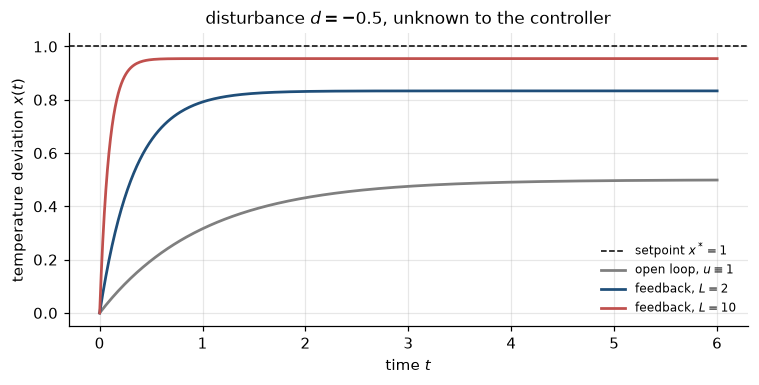

In [2]:
d = -0.5                                   # unknown disturbance
t = np.linspace(0, 6, 400)


def thermostat(rule):
    rhs = lambda s, x: -x + rule(x) + d
    return solve_ivp(rhs, (0, 6), [0.0], t_eval=t, rtol=1e-10, atol=1e-12).y[0]


fig, ax = plt.subplots(figsize=(7, 3.6))
ax.axhline(1.0, color="black", lw=1, ls="--", label="setpoint $x^*=1$")
ax.plot(t, thermostat(lambda x: 1.0), color=COLORS["reference"], label="open loop, $u\\equiv1$")
for L, style in ((2.0, "-"), (10.0, "-")):
    ax.plot(t, thermostat(lambda x, L=L: 1.0 + L * (1.0 - x)), style,
            color=COLORS["state"] if L == 2 else COLORS["control"], label=f"feedback, $L={L:g}$")
ax.set_xlabel("time $t$"); ax.set_ylabel("temperature deviation $x(t)$")
ax.set_title("disturbance $d=-0.5$, unknown to the controller"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 1.** The thermostat $x'=-x+u+d$ with $d=-0.5$, from $x(0)=0$, under the open-loop control $u\equiv1$ and under the feedback $u=1+L(1-x)$ for $L=2$ and $L=10$.

*Interpretation (answer to the prediction).* The open-loop control was computed for $d=0$, and it settles at $1+d=0.5$. Feedback measures the actual state and corrects the error: it settles at $1+d/(1+L)$, that is $0.83$ for $L=2$ and $0.95$ for $L=10$, and it gets there faster. In this example feedback attenuates the steady effect of the unknown constant disturbance by the factor $1/(1+L)$; it does not remove it, and other disturbances or model errors would need their own analysis. It is not free, though: the gain is a design choice, and §4 shows that "more" is not always "better".

## 4. The overdamping paradox
`CORE`

The first rigorous analysis of a regulator, the steam-engine governor, was done by J. C. Maxwell in 1868 (p. 23). It explained why apparently more elaborate regulators could behave badly. The phenomenon is now called **overdamping**, and it already shows up in the simplest example.

**The model.** Without friction, the linearized pendulum $x_1''+x_1=0$ conserves its energy
$$
e(t)=\tfrac12\big(x_1(t)^2+x_1'(t)^2\big).
$$
With friction proportional to the velocity, as on p. 23,
$$
x_1''+x_1=-kx_1',\qquad k>0 .
$$
In the language of §§1–3 this is **E1 under the feedback** $u=-kx_2$, with state matrix $A_k=\begin{pmatrix}0&1\\-1&-k\end{pmatrix}$ (`damped_oscillator(k)` in `src/control_utils.py`). Damping *is* a feedback law: the control opposes the measured velocity.

**Energy decreases.** Along solutions,
$$
e'(t)=x_1x_1'+x_1'x_1''=x_1'\,(x_1+x_1'')=-k\,(x_1')^2\;\le\;0 .
$$
So more damping removes energy faster *at each instant*, for the same velocity. Does it follow that a larger $k$ always brings the system to rest faster?

> **Predict.** Among $k\in\{0.5,\,1,\,2,\,4,\,8\}$, which value makes the solution starting from $x^0=(1,0)$ decay fastest? Write down your guess before running the next cell.

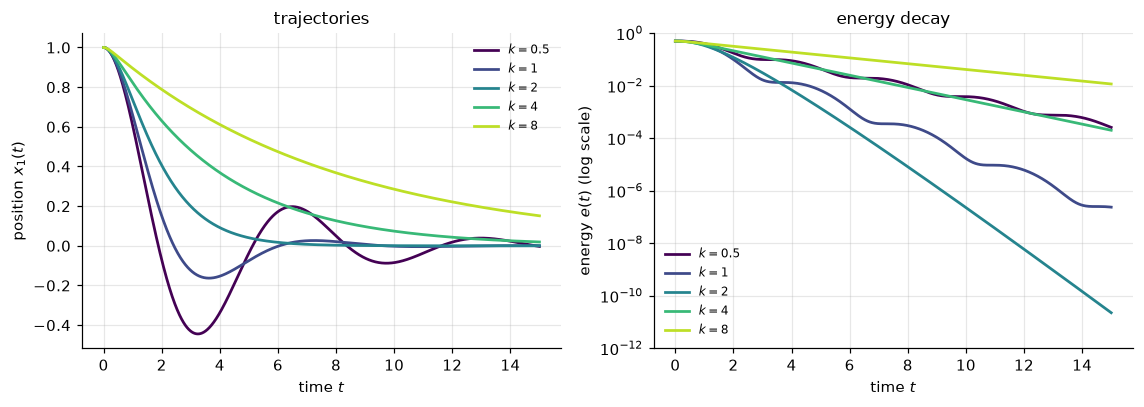

In [3]:
ks = [0.5, 1.0, 2.0, 4.0, 8.0]
x0 = np.array([1.0, 0.0])
T = 15.0
t = np.linspace(0, T, 1500)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(ks)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))
for k, c in zip(ks, colors):
    A_k, B = damped_oscillator(k)
    x = simulate(A_k, B, lambda s: np.zeros(1), x0, T, t)
    energy = 0.5 * np.sum(x**2, axis=1)
    ax1.plot(t, x[:, 0], color=c, label=f"$k={k:g}$")
    ax2.semilogy(t, energy, color=c, label=f"$k={k:g}$")
ax1.set_xlabel("time $t$"); ax1.set_ylabel("position $x_1(t)$"); ax1.set_title("trajectories")
ax2.set_xlabel("time $t$"); ax2.set_ylabel(r"energy $e(t)$ (log scale)"); ax2.set_title("energy decay")
ax2.set_ylim(1e-12, 1); ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 2.** Solutions of $x_1''+kx_1'+x_1=0$ from $x^0=(1,0)$ for five damping coefficients. *Left:* position. *Right:* energy $e(t)=\tfrac12(x_1^2+x_2^2)$ on a logarithmic scale.

*Interpretation (answer to the prediction).* Small damping ($k=0.5$, $1$) gives oscillations whose envelope decays slowly. The fastest decay is at $k=2$. For $k=4$ and $k=8$ there are no oscillations, but the return to rest is *slower*, and slower still for $k=8$. The next subsection explains why.

### 4.1 Why: the characteristic roots

Solutions $x_1=e^{\lambda t}$ of $x_1''+kx_1'+x_1=0$ require $\lambda^2+k\lambda+1=0$, that is (p. 24)
$$
\lambda_\pm=\frac{-k\pm\sqrt{k^2-4}}{2}.
$$
Every solution is a combination of $e^{\lambda_+t}$ and $e^{\lambda_-t}$ (or of $e^{-t}$ and $te^{-t}$ when $k=2$). Its decay is dictated by the root with the **largest real part**. We call
$$
r(k)=-\max\operatorname{Re}\lambda_\pm
$$
the **decay rate**: solutions behave like $e^{-r(k)t}$, up to a factor $t$ in the critical case.

- **Underdamping, $0<k<2$.** The roots are complex, $\lambda_\pm=-\tfrac k2\pm\tfrac i2\sqrt{4-k^2}$, so the solutions oscillate, with $r(k)=k/2$. Here more damping does help.
- **Critical damping, $k=2$.** There is a double root $\lambda=-1$, so $r(2)=1$. For $x^0=(1,0)$ the solution is $x_1(t)=(1+t)e^{-t}$. The rate $r$ describes the *asymptotic* decay; the factor $(1+t)$ and the initial state shape the transient, so the fastest asymptotic rate is not a statement about every finite time.
- **Overdamping, $k>2$.** There are two negative real roots. The slow one is $\lambda_+$, and multiplying numerator and denominator by $k+\sqrt{k^2-4}$ gives
$$
\lambda_+=\frac{-k+\sqrt{k^2-4}}{2}\cdot\frac{k+\sqrt{k^2-4}}{k+\sqrt{k^2-4}}=\frac{(k^2-4)-k^2}{2\big(k+\sqrt{k^2-4}\big)}=\frac{-2}{k+\sqrt{k^2-4}} .
$$
Hence $r(k)=\dfrac{2}{k+\sqrt{k^2-4}}$, which *decreases* as $k$ grows, and $r(k)\to0$ as $k\to\infty$ (in fact $r(k)\approx1/k$).

Altogether,
$$
r(k)=\begin{cases}k/2, & 0<k\le2,\\[2pt] \dfrac{2}{k+\sqrt{k^2-4}}, & k\ge2,\end{cases}
\qquad\text{maximal at }k=2,\ r(2)=1 .
$$

**Interpretation.** Very strong friction kills the velocity almost immediately, and then the position creeps back to rest on the slow time scale $1/r(k)\approx k$. As the slides put it, this "confirms the prediction that optimal controls and strategies are often complex and that they do not necessarily obey the very first intuition" (p. 24).

> **Remark on the source slides.** On p. 24 the rationalized root is written $\lambda_+=-4/(k+\sqrt{k^2-4})$. The correct value is $-2/(k+\sqrt{k^2-4})$, as derived above; the factor $\tfrac12$ of $\lambda_\pm$ was dropped. The conclusion of the slide, $\lambda_+\to0$ as $k\to\infty$, is unaffected.

max |formula - eigenvalue computation| = 1.5e-15


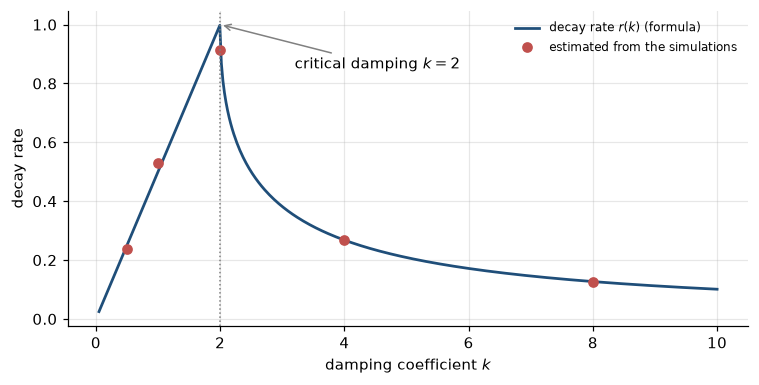

In [4]:
k_grid = np.linspace(0.05, 10, 400)
r_formula = np.where(k_grid <= 2, k_grid / 2, 2 / (k_grid + np.sqrt(np.maximum(k_grid**2 - 4, 0))))
r_eig = np.array([-spectral_abscissa(damped_oscillator(k)[0]) for k in k_grid])
print(f"max |formula - eigenvalue computation| = {np.abs(r_formula - r_eig).max():.1e}")

# Rates estimated from the simulations of Figure 2: slope of log|x(t)| on the late window t in [8, 15].
late = t >= 8
r_sim = []
for k in ks:
    A_k, B = damped_oscillator(k)
    x = simulate(A_k, B, lambda s: np.zeros(1), x0, T, t)
    slope = np.polyfit(t[late], np.log(np.linalg.norm(x[late], axis=1)), 1)[0]
    r_sim.append(-slope)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(k_grid, r_formula, color=COLORS["state"], label="decay rate $r(k)$ (formula)")
ax.plot(ks, r_sim, "o", color=COLORS["control"], label="estimated from the simulations")
ax.axvline(2, color=COLORS["reference"], ls=":", lw=1)
ax.annotate("critical damping $k=2$", xy=(2, 1), xytext=(3.2, 0.85), arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("damping coefficient $k$"); ax.set_ylabel("decay rate"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 3.** The decay rate $r(k)=-\max\operatorname{Re}\lambda_\pm$ of $x_1''+kx_1'+x_1=0$ against $k$: the formula of §4.1 (curve, which coincides with a numerical eigenvalue computation to rounding precision) and the rates estimated from the simulations of Figure 2 by fitting the slope of $\log|x(t)|$ for $8\le t\le15$ (dots).

*Interpretation.* The rate grows linearly up to $k=2$ and then decreases towards zero. The estimated rates agree with the formula. At $k=2$ the estimate is slightly lower, because the factor $(1+t)$ of the critical solution bends the logarithmic slope, and in the underdamped cases the estimate carries a small oscillation. **Increasing the damping indefinitely does not accelerate the decay.** [Notebook 05](05_feedback_stabilization.ipynb) returns to this example from the point of view of stabilization, and shows how full-state feedback can achieve any decay rate (p. 131).

## 5. Control ↔ ML: two forward connections
`CORE` · *Previews only; both are developed later.*

- **Feedback ↔ reinforcement learning.** The slides describe reinforcement learning as "learning based on feedback": there are no correct input–output pairs, but there is a reward (p. 70). The common idea is that an action depends on the observed state. The difference is that a feedback law is *designed* from a known model, while in reinforcement learning a policy is *learned* from rewards ([notebook 09](09_machine_learning_foundations_generalization.ipynb)).
- **Damping ↔ momentum methods** *(a connection proposed in these notebooks)*. The "heavy ball" picture of momentum in gradient descent (p. 286) is a damped second-order dynamics. Its damping parameter can be too small, giving oscillations, or too large, giving slow creeping, exactly as in Figure 3 ([notebook 11](11_optimization_algorithms_ml.ipynb)).

## 6. A short timeline
`DEEPER LOOK` · *optional, historical*

- Antiquity: automation as a source of freedom, in a passage of Aristotle's *Politics* quoted on p. 9; irrigation and aqueducts with regulators (pp. 21–22).
- 17th–18th century: pendulum clocks (Huygens, Hooke) and the regulator of windmills, applied by J. Watt to the steam engine (p. 22).
- 1868: Maxwell's analysis of the governor and the overdamping phenomenon (pp. 23–24). In 1907, H. R. Hall stressed that regulators *need* fluctuations, which should be diminished but not removed (p. 16).
- 1920s–1930s: feedback in telecommunications (Bell Laboratories) and the rapid spread of automatic control (pp. 13, 25). Two approaches: state space (ODEs) and frequency domain (Fourier) (p. 26).
- 1948: N. Wiener's *Cybernetics*, "the science of control and communication in animals and machines" (p. 19).
- 1960s: Kalman (filtering and the algebraic approach, notebook 02), Pontryagin (the maximum principle, a generalization of Lagrange multipliers) and Bellman (dynamic programming) (p. 27).
- Later: nonlinear, stochastic and infinite-dimensional (PDE) systems (p. 28), with applications from acoustics and quantum control to aerospace, biomedicine and energy (pp. 29–38, 137–140).

## 7. Common misconceptions
`CORE`

**"More damping, or more gain, is always better."** No. Damping beyond $k=2$ slows the return to rest (§4).

**"A control that reaches the target is the optimal control."** Reaching the target is controllability. If it can be reached, it can usually be reached in many ways, and optimality is a separate criterion (§2).

**"Stabilization means reaching the equilibrium at time $T$."** No. Stabilization is asymptotic. For the damped oscillator, a linear autonomous feedback, $x(t)\ne0$ for all $t$ when $x^0\ne0$. Reaching a state at a fixed time is controllability.

**"Open-loop control is useless in practice."** Open-loop controls are what controllability theory constructs (notebooks 02–04). Feedback can add robustness to some unmodelled effects, such as the constant disturbance of §3.

## 8. What you should remember
`CORE`

1. A control problem consists of a state equation, a set of admissible controls and an objective.
2. Controllability: *can* the target be reached? Optimal control: which admissible control is *best*? Stabilization: is there a *rule* $u=F(x)$ that makes the equilibrium asymptotically stable (stable and attracting), here for every initial state?
3. Open loop: $u=u(t)$, computed in advance. Closed loop: $u=F(x(t))$, computed in real time; in the thermostat it divides the steady effect of a constant disturbance by $1+L$.
4. Viscous damping is the feedback $u=-kx_2$, and it makes the energy non-increasing: $e'=-k(x_1')^2$.
5. The decay rate is $r(k)=k/2$ for $k\le2$ and $2/(k+\sqrt{k^2-4})$ for $k\ge2$: it is maximal at critical damping, $k=2$, and tends to $0$ as $k\to\infty$.

## 9. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (which question is it?).** Classify each problem as controllability, optimal control or stabilization, and say what the unknown is: (a) keep an inverted pendulum upright despite small pushes; (b) bring a crane load from rest at one point to rest at another point in exactly 20 s; (c) among all ways of doing (b), find the one using the least energy; (d) cruise control keeps a car at 100 km/h on hills.

**Exercise 2 ★★ (the oscillator).** (a) Verify that $x_1(t)=(1+t)e^{-t}$ solves $x_1''+2x_1'+x_1=0$ with $x_1(0)=1$, $x_1'(0)=0$. (b) For $k>2$, show that $r(k)=2/(k+\sqrt{k^2-4})$ is strictly decreasing, and that $k\,r(k)\to1$ as $k\to\infty$. (c) For $k>2$ and $x^0=(1,0)$, write the solution as $c_+e^{\lambda_+t}+c_-e^{\lambda_-t}$ and show that both coefficients are nonzero, so that the slow rate is actually observed.

**Exercise 3 ★★ (open loop versus feedback).** For the thermostat $x'=-x+u+d$ of §3 with setpoint $1$: (a) compute the limit of $x(t)$ for the open-loop control $u\equiv1$ and for the feedback $u=1+L(1-x)$, for a constant unknown $d$; (b) show that the feedback error tends to $0$ as $L\to\infty$; (c) now assume that the *measurement* is wrong by a constant bias $\beta$, so the feedback uses $x+\beta$ instead of $x$. What is the limit, and what does a large $L$ do to the effect of $\beta$?

**Exercise 4 ★★ (energy is not enough).** For $x_1''+kx_1'+x_1=0$ we showed $e'=-k(x_1')^2\le0$. (a) Does this inequality alone prove that $e(t)\to0$? Find the weak point. (b) Use the characteristic roots to prove that $e(t)\to0$ exponentially for every $k>0$.

**Exercise 5 ★★★ (a stiffer spring).** Consider $x_1''+kx_1'+\omega^2x_1=0$ with $\omega>0$. Modify the code of Figure 3 to compute the decay rate $r(k;\omega)$ numerically for $\omega\in\{0.5,1,2\}$ and $0<k\le10$. Find the best damping $k^*(\omega)$ and the best rate, and conjecture formulas. Then prove them from the characteristic roots.

In [5]:
# TODO: student exercise (Exercise 5)
# Build A = [[0, 1], [-omega**2, -k]] and compute the decay rate -max Re(eig(A)) on a grid of k,
# for omega in [0.5, 1, 2]. Plot the rates against k and locate the maximum.

def decay_rate(k, omega):
    ...  # your code here
    return None

## Where are we going?
`CORE`

We have three questions and one example. [Notebook 02](02_linear_control_kalman.ipynb) takes the first question, controllability, for linear systems $x'=Ax+Bu$. It asks when a few controls can steer a system between arbitrary states, and it answers with the Kalman rank condition and an explicit steering control. Feedback stabilization, which explains §4 in general, is the subject of [notebook 05](05_feedback_stabilization.ipynb).

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Ingredients | 10–11 | State equation $A(y)=f(v)$, admissible controls, target; model classes |
| §2 Three questions | 12 | Optimal control, controllability (exact and approximate), stabilization/feedback |
| §3 Feedback | 13–15 | Concept of feedback, Bell Laboratories, cause–effect–cause; thermostat, aircraft, noise reduction |
| §4 Overdamping | 22–24 | Maxwell; energy of the pendulum; damped equation; roots and overdamping |
| §5 Previews | 70, 286 | Reinforcement learning as feedback; momentum as a heavy ball |
| §6 Timeline | 7–9, 16, 19, 21–22, 25–38, 137–140 | Origins, Hall's quote, cybernetics, 1960s, PDE control and applications |

**Pedagogical additions:** the ODE formulation and E1 (§1), the comparison table (§2), the thermostat model and Figure 1 (§3), the energy identity, the full case analysis and Figures 2–3 (§4). **Correction of the slides:** the rationalized root on p. 24 (remark in §4.1).